# Bodrum Hotel & Destination Intelligence
## 16 - Trip.com Review Audit & Cleaning

In [1]:

import sys, subprocess
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import os

REPO_ROOT = r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews"
FIG_DIR = REPO_ROOT + r"\reports\figures\tripcom_audit"
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.max_columns", 50)


## C1-C2: Rebuild clean dataset from raw (source of truth)

In [2]:

result = subprocess.run([sys.executable, REPO_ROOT + r"\scripts\analysis\build_tripcom_clean_dataset.py"],
                         capture_output=True, text=True, cwd=REPO_ROOT)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)


Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\data\processed\tripcom_reviews_clean.csv (3013 clean rows from 3013 raw rows)
Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\reports\tripcom_input_inventory.csv
Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\reports\tripcom_duplicate_audit.csv (0 hash groups with >1 occurrence)
Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\reports\tripcom_audit_summary.txt



In [3]:

clean = pd.read_csv(REPO_ROOT + r"\data\processed\tripcom_reviews_clean.csv")
inventory = pd.read_csv(REPO_ROOT + r"\reports\tripcom_input_inventory.csv")
dup_audit = pd.read_csv(REPO_ROOT + r"\reports\tripcom_duplicate_audit.csv")
print("clean rows:", len(clean), "| hotels:", clean['hotel_id'].nunique())
clean.head(3)


clean rows: 3013 | hotels: 94


,review_id,hotel_id,hotel_name,area,source_platform,review_text,review_text_clean,source_rating,source_rating_max,rating_5_scale,rating_group,review_date,review_date_raw,stay_year,stay_month,stay_date_raw,traveler_type,traveler_type_raw,room_type,room_type_raw,reviewer_location,reviewer_country,customer_tier,customer_tier_raw,reviewer_review_count,review_hash,source_url,collected_at,quality_flags
0,1,BOD002,Armonia Holiday Village & Spa,Akyarlar,trip,Guest User,Guest User,10.0,10.0,5.0,HIGH,2026-06-21,"Posted June 21, 2026",NaN,NaN,"I’ve stayed in more than 30 hotels, hostels, a...",FAMILY,Family,UNKNOWN,NaN,aLper B,aLper B,OTHER,Verified by,NaN,478894bde8a5434e1aca0511e25217fbebbe0bc64708de...,https://www.trip.com/hotels/bodrum-hotel-detai...,2026-08-26T23:54:45Z,VERY_SHORT
1,2,BOD002,Armonia Holiday Village & Spa,Akyarlar,trip,"This is a great hotel, best beach, great food,...","This is a great hotel, best beach, great food,...",10.0,10.0,5.0,HIGH,2026-06-21,"Posted June 21, 2026",2026.0,6.0,Stayed in June 2026,FAMILY,Family,UNKNOWN,NaN,NaN,NaN,NONE,NaN,NaN,89b2a2f5d16bb80d12275b9d89dc106691f88d37c6809e...,https://www.trip.com/hotels/bodrum-hotel-detai...,2026-08-26T23:54:45Z,NaN
2,3,BOD002,Armonia Holiday Village & Spa,Akyarlar,trip,"Everything is excellent! Animation, mini disco...","Everything is excellent! Animation, mini disco...",10.0,10.0,5.0,HIGH,2026-08-21,"Posted August 21, 2026",2026.0,8.0,Stayed in August 2026,UNKNOWN,NaN,UNKNOWN,NaN,NaN,NaN,NONE,NaN,NaN,a65927cb4cd7acff6166824495c757572d01e5a20c2526...,https://www.trip.com/hotels/bodrum-hotel-detai...,2026-08-26T23:54:45Z,NaN


## C3: Identity audit (wrong entity contamination must be 0)
By construction, trip_adapter.py never writes a row for a WRONG_ENTITY result - this reads the
scrape_status log to confirm zero rows came from a wrong-entity or review-required source.

In [4]:

status = pd.read_csv(REPO_ROOT + r"\reports\multiplatform_scrape_status.csv")
trip_status = status[status["platform"] == "trip"]
wrong_rows_written = trip_status[trip_status["status"] == "WRONG_ENTITY"]["rows_added"].sum()
review_required_rows_written = trip_status[trip_status["status"] == "NAME_REVIEW_REQUIRED"]["rows_added"].sum()
print("wrong_entity_rows_written:", wrong_rows_written, "| review_required_rows_written:", review_required_rows_written)
assert wrong_rows_written == 0 and review_required_rows_written == 0, "SAFETY VIOLATION"
print("OK: 0 contamination confirmed")


wrong_entity_rows_written: 0 | review_required_rows_written: 0
OK: 0 contamination confirmed


## C4: Duplicate audit

In [5]:

print(f"{len(dup_audit)} cross-hotel duplicate hash groups (should be 0 or explainable)")
dup_audit.head()


0 cross-hotel duplicate hash groups (should be 0 or explainable)


,review_hash,occurrence_count,hotel_ids


## C6-C7: Rating (raw preserved, normalized 5-scale, explicit thresholds)

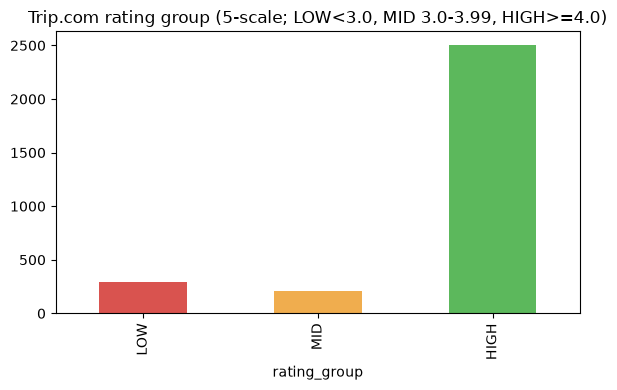

In [6]:

rating_dist = clean["rating_group"].value_counts()
rating_dist.to_csv(REPO_ROOT + r"\reports\tripcom_rating_audit.csv")

fig, ax = plt.subplots(figsize=(6,4))
rating_dist.reindex(["LOW","MID","HIGH"]).plot(kind="bar", ax=ax, color=["#d9534f","#f0ad4e","#5cb85c"])
ax.set_title("Trip.com rating group (5-scale; LOW<3.0, MID 3.0-3.99, HIGH>=4.0)")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\rating_group_distribution.png", dpi=110)
plt.show()


### Grafik nasıl okunur?
Trip.com'un ham 0-10 puanı 5'lik ölçeğe normalize edilip (rating_5_scale), açıkça belirtilen eşiklerle gruplanmıştır.
### Ne görüyoruz?
Trip.com misafirlerinin genel memnuniyet dağılımı.
### Neden önemli?
Google Travel ile karşılaştırma normalize edilmiş 5-scale üzerinden yapılacağı için bu adım kritik.
### Dikkat edilmesi gereken nokta
Ham puan hiçbir zaman üzerine yazılmadı; rating_5_scale ayrı bir kolondur.

## C8-C9: Review date & stay date coverage

In [7]:

date_coverage = clean["review_date"].notna().mean() * 100
stay_coverage = clean["stay_year"].notna().mean() * 100
date_audit = pd.DataFrame([{"review_date_coverage_pct": round(date_coverage,1),
                             "stay_date_coverage_pct": round(stay_coverage,1)}])
date_audit.to_csv(REPO_ROOT + r"\reports\tripcom_date_audit.csv", index=False)
date_audit


,review_date_coverage_pct,stay_date_coverage_pct
0,99.6,97.9


## C10-C11: Traveler type & room type coverage

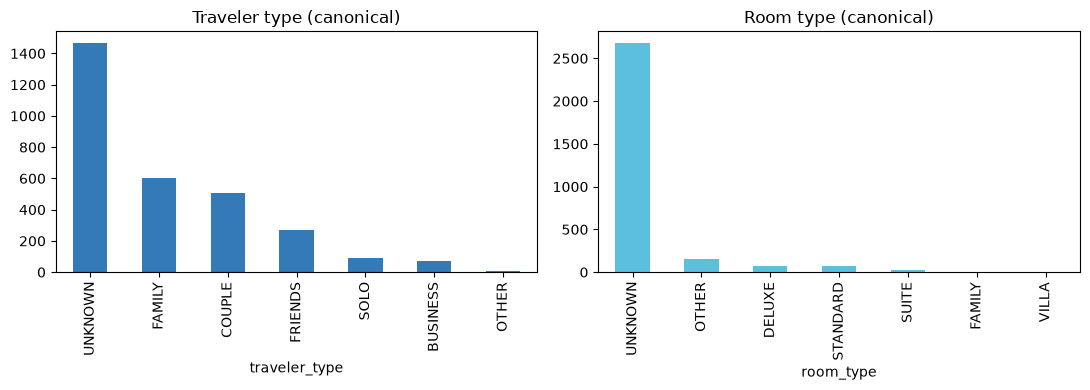

In [8]:

traveler_cov = clean["traveler_type"].value_counts()
traveler_cov.to_csv(REPO_ROOT + r"\reports\tripcom_traveler_type_coverage.csv")
room_cov = clean["room_type"].value_counts()
room_cov.to_csv(REPO_ROOT + r"\reports\tripcom_room_type_coverage.csv")

fig, axes = plt.subplots(1, 2, figsize=(11,4))
traveler_cov.plot(kind="bar", ax=axes[0], color="#337ab7", title="Traveler type (canonical)")
room_cov.plot(kind="bar", ax=axes[1], color="#5bc0de", title="Room type (canonical)")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\traveler_and_room_type.png", dpi=110)
plt.show()


### Grafik nasıl okunur?
Sol: misafir tipi (Family/Couple/Solo/Friends/vb.) dağılımı; sağ: oda tipi kategorileri.
### Ne görüyoruz?
Trip.com'un sağladığı ekstra bağlamsal alanların (Google Travel'de olmayan) kapsamı.
### Neden önemli?
Segment analizinin (notebook 17) hangi ölçekte güvenilir olacağını gösterir.
### Dikkat edilmesi gereken nokta
UNKNOWN/OTHER oranı yüksekse segment bulguları temkinli yorumlanmalı.

## C12: Reviewer location / country coverage

In [9]:

country_cov = clean["reviewer_country"].value_counts()
country_cov.to_csv(REPO_ROOT + r"\reports\tripcom_reviewer_location_coverage.csv")
country_cov.head(15)


reviewer_country
Turkey                  89
Russia                  83
China                   36
United Kingdom          26
Saudi Arabia            20
United States           16
United Arab Emirates    12
Germany                 11
France                  11
Slovenia                 4
Australia                4
Netherlands              4
Kazakhstan               3
Singapore                3
Hong Kong, China         2
Name: count, dtype: int64

## C16: Missing values & cleaning log

In [10]:

key_cols = ["review_text_clean","source_rating","review_date","traveler_type_raw","room_type_raw","reviewer_country"]
missing = clean[key_cols].isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(clean) * 100).round(1)
missing.to_csv(REPO_ROOT + r"\reports\tripcom_missing_values.csv")
missing


,missing_count,missing_pct
review_text_clean,0,0.0
source_rating,0,0.0
review_date,12,0.4
traveler_type_raw,1468,48.7
room_type_raw,2682,89.0
reviewer_country,2663,88.4


In [11]:

ui_leak_rows = clean[clean["quality_flags"].str.contains("UI_LEAKAGE", na=False)]
cleaning_log = pd.DataFrame([{
    "duplicates_dropped": "see tripcom_audit_summary.txt",
    "empty_text_dropped": "see tripcom_audit_summary.txt",
    "ui_leakage_flagged_not_dropped": len(ui_leak_rows),
}])
cleaning_log.to_csv(REPO_ROOT + r"\reports\tripcom_cleaning_log.csv", index=False)
print(f"{len(ui_leak_rows)} rows flagged as suspected UI leakage (kept, not silently dropped):")
ui_leak_rows[["hotel_id","review_text","reviewer_location","quality_flags"]].head(10)


33 rows flagged as suspected UI leakage (kept, not silently dropped):


,hotel_id,review_text,reviewer_location,quality_flags
39,BOD004,Anonymous User,Show More,VERY_SHORT;UI_LEAKAGE_LOCATION
50,BOD007,Black Diamond,Show More,VERY_SHORT;UI_LEAKAGE_LOCATION;UI_LEAKAGE_REVI...
72,BOD010,What guests say,Show More,VERY_SHORT;UI_LEAKAGE_LOCATION
74,BOD011,Killian Killian,Show More,VERY_SHORT;UI_LEAKAGE_LOCATION
85,BOD012,Nurullah Dinçer,Show More,VERY_SHORT;UI_LEAKAGE_LOCATION
96,BOD013,Dreamer04731033535,Show More,VERY_SHORT;UI_LEAKAGE_LOCATION
102,BOD013,"What a place we have been,i'd like to thank to...",Show More,UI_LEAKAGE_LOCATION
103,BOD013,"Areas are under development, dangerous traffic",Show More,UI_LEAKAGE_LOCATION
104,BOD014,Overall pleasant place. They need to upgrade t...,Show More,UI_LEAKAGE_LOCATION
109,BOD014,Verified by,NaN,VERY_SHORT;UI_LEAKAGE_REVIEW_TEXT


### Grafik nasıl okunur? (tablo)
Bu tablo, incelemede metninin ya da konum alanının aslında bir arayüz etiketi (örn. "Show More", "Black Diamond")
olduğu şüphelenilen satırları listeler.
### Ne görüyoruz?
Trip.com scraper'ının bazı kartlarda yanlış DOM elemanını okuduğu nadir durumlar.
### Neden önemli?
Bu satırlar SİLİNMEDİ (B18/C-politikası: yalnız tam duplicate ve boş metin silinir) - sadece işaretlendi, şeffaflık için.
### Dikkat edilmesi gereken nokta
Sayı küçükse (<%5) NLP/segment bulgularını önemli ölçüde etkilemez.

## Notebook 16 - Final Answers

In [12]:

answers = {
    "raw_total_rows": int(inventory["row_count"].sum()),
    "clean_total_rows": int(len(clean)),
    "hotel_count": int(clean['hotel_id'].nunique()),
    "wrong_entity_contamination": int(wrong_rows_written),
    "date_coverage_pct": round(date_coverage, 1),
    "stay_date_coverage_pct": round(stay_coverage, 1),
    "traveler_type_coverage_pct": round((clean['traveler_type'] != 'UNKNOWN').mean()*100, 1),
    "room_type_coverage_pct": round((clean['room_type'] != 'UNKNOWN').mean()*100, 1),
    "reviewer_location_coverage_pct": round(clean['reviewer_country'].notna().mean()*100, 1),
    "ui_leakage_flagged_rows": int(len(ui_leak_rows)),
    "analysis_readiness": "READY for segment analysis (notebook 17)",
}
for k, v in answers.items():
    print(f"{k}: {v}")


raw_total_rows: 3013
clean_total_rows: 3013
hotel_count: 94
wrong_entity_contamination: 0
date_coverage_pct: 99.6
stay_date_coverage_pct: 97.9
traveler_type_coverage_pct: 51.3
room_type_coverage_pct: 11.0
reviewer_location_coverage_pct: 11.6
ui_leakage_flagged_rows: 33
analysis_readiness: READY for segment analysis (notebook 17)
